Loading data...


/var/folders/zh/kqdj54z55lxg3q20031d0r540000gn/T/ipykernel_11426/3477109080.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_purchased, x='Month', order=month_order, palette='viridis')


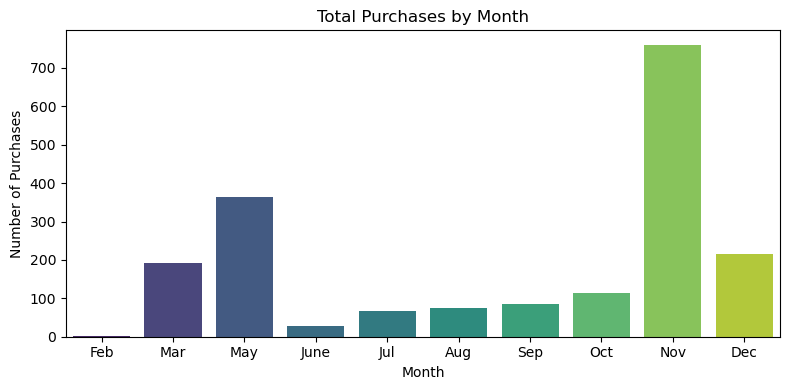

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# 1. Load data 
print("Loading data...")
online_shoppers = fetch_ucirepo(id=468)
X = online_shoppers.data.features
y = online_shoppers.data.targets

# 2. Sort months in chronological order
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 3. Filter data for completed purchases (Revenue = 1)
df_purchased = X[y['Revenue'] == 1]

# 4. Plot monthly total purchases
plt.figure(figsize=(8, 4))
sns.countplot(data=df_purchased, x='Month', order=month_order, palette='viridis')

plt.title('Total Purchases by Month')
plt.xlabel('Month')
plt.ylabel('Number of Purchases')
plt.tight_layout()
plt.show()

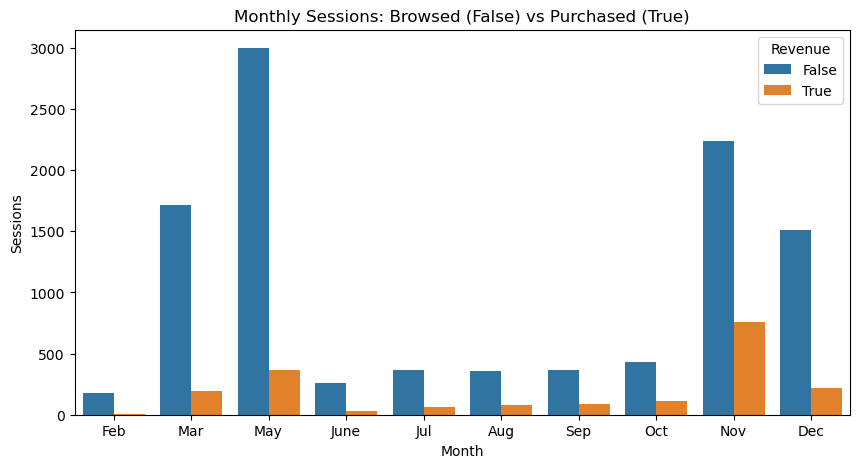

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# 1. Load Data
data = fetch_ucirepo(id=468)
df = data.data.features
df['Revenue'] = data.data.targets['Revenue']

# 2. Sort Months
months = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# 3. Plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Month', hue='Revenue', order=months)

plt.title('Monthly Sessions: Browsed (False) vs Purchased (True)')
plt.xlabel('Month')
plt.ylabel('Sessions')
plt.show()

/var/folders/zh/kqdj54z55lxg3q20031d0r540000gn/T/ipykernel_11426/3427831728.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


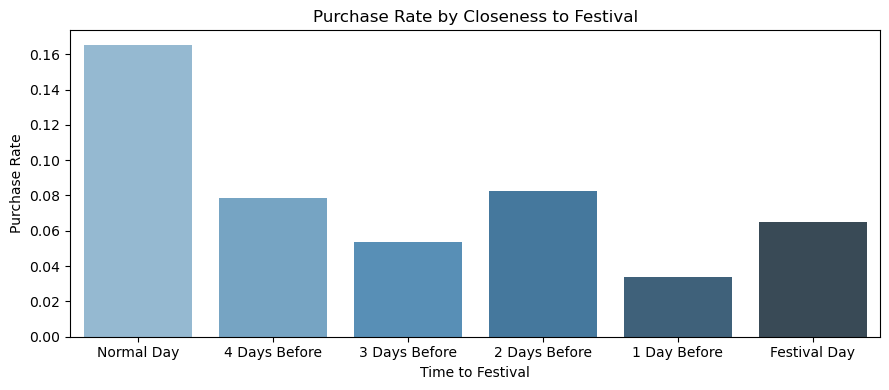

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map float numbers to simple English labels
day_map = {
    0.0: 'Normal Day',
    0.2: '4 Days Before',
    0.4: '3 Days Before',
    0.6: '2 Days Before',
    0.8: '1 Day Before',
    1.0: 'Festival Day',
}

df['SpecialDay_Text'] = df['SpecialDay'].map(day_map)

# Set day order
day_order = [
    'Normal Day',
    '4 Days Before',
    '3 Days Before',
    '2 Days Before',
    '1 Day Before',
    'Festival Day',
]

# Plot
plt.figure(figsize=(9, 4))
sns.barplot(
    data=df,
    x='SpecialDay_Text',
    y='Revenue',
    order=day_order,
    errorbar=None,
    palette='Blues_d',
)

plt.title('Purchase Rate by Closeness to Festival')
plt.xlabel('Time to Festival')
plt.ylabel('Purchase Rate')
plt.tight_layout()
plt.show()

Total Sessions: 12330
Purchased Sessions: 1908
Conversion Rate: 15.47%


/var/folders/zh/kqdj54z55lxg3q20031d0r540000gn/T/ipykernel_11426/4038590503.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Revenue', palette='Set2')


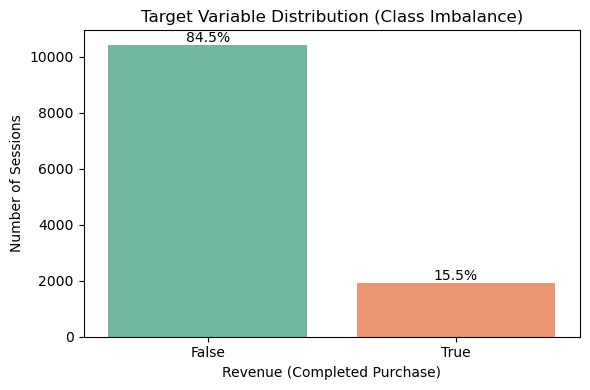

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# 1. Load Data
data = fetch_ucirepo(id=468)
df = data.data.targets

# 2. Calculate Conversion Rate
total = len(df)
purchased = df['Revenue'].sum()
conversion_rate = (purchased / total) * 100

print(f'Total Sessions: {total}')
print(f'Purchased Sessions: {purchased}')
print(f'Conversion Rate: {conversion_rate:.2f}%')

# 3. Plot Target Class Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Revenue', palette='Set2')

plt.title('Target Variable Distribution (Class Imbalance)')
plt.xlabel('Revenue (Completed Purchase)')
plt.ylabel('Number of Sessions')

# Add percentages on top of bars
for p in ax.patches:
    percentage = f'{(100 * p.get_height() / total):.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.show()

#Low Conversion: Out of every 100 website visitors, only 15 buy something, while 85 leave empty-handed.
#Imbalanced Data: The number of "Non-Buyers" (84.5%) is way larger than "Buyers" (15.5%)

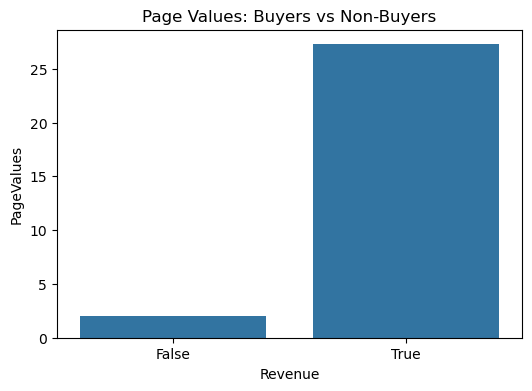

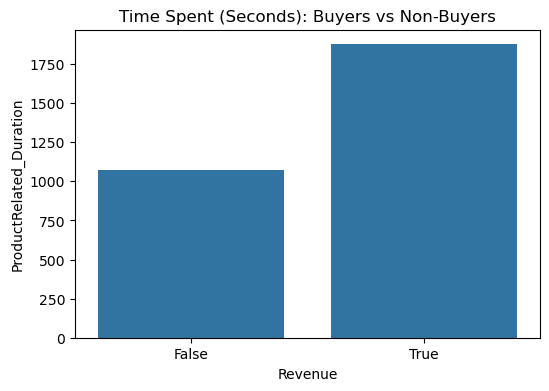

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


dataset = fetch_ucirepo(id=468)
df = dataset.data.original


plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Revenue', y='PageValues', errorbar=None)
plt.title('Page Values: Buyers vs Non-Buyers')
plt.show()


plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Revenue', y='ProductRelated_Duration', errorbar=None)
plt.title('Time Spent (Seconds): Buyers vs Non-Buyers')
plt.show()

Figure: Key Differences (Buyers vs Non-Buyers)
High Page Value: Buyers (Revenue = True) visit pages with much higher PageValues than non-buyers.
More Browsing Time: Buyers spend roughly double the time looking at product pages (ProductRelated_Duration).
Takeaway: Visiting high-value pages and spending more time on products are the two strongest signals of real buyers.